In [1]:
import os

In [2]:
print(len(os.listdir("/content/drive/MyDrive/VideoTensors/videoTensorFull/videosTensors1000")))
print(len(os.listdir("/content/drive/MyDrive/VideoTensors/Test/Test")))

8480
4242


In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import os
import pandas as pd
import numpy as np
import random

class MotionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, pt_folder: str, training: bool = True,
                 max_points: int = 1000, augment_prob: float = 0.7):
        self.df = df.reset_index(drop=True)
        self.pt_folder = pt_folder
        self.training = training
        self.max_points = max_points
        self.augment_prob = augment_prob
        print(f"Initialized MotionDataset with {len(self.df)} samples. Training: {self.training}")

    def __len__(self) -> int:
        return len(self.df)

    def _normalize_coordinates(self, coords: torch.Tensor, height: float = 384.0, width: float = 512.0) -> torch.Tensor:
        """Normalize coordinates and add robustness"""
        coords_norm = coords.clone()
        coords_norm[..., 0] = coords_norm[..., 0] / width   # x
        coords_norm[..., 1] = coords_norm[..., 1] / height  # y

        # Clamp to reasonable range to handle outliers
        coords_norm = torch.clamp(coords_norm, -0.1, 1.1)
        return coords_norm

    def _calculate_features(self, coords: torch.Tensor, visibility: torch.Tensor) -> torch.Tensor:
        """Calculate velocity and acceleration features"""
        seq_len, num_points, _ = coords.shape

        # Velocity (first derivative)
        velocity = torch.zeros_like(coords)
        if seq_len > 1:
            velocity[1:] = coords[1:] - coords[:-1]

        # Smooth velocity using visibility
        for t in range(1, seq_len):
            mask = visibility[t].squeeze(-1) > 0.5
            if mask.any():
                velocity[t][~mask] = 0  # Zero out velocity for invisible points

        # Acceleration (second derivative)
        acceleration = torch.zeros_like(coords)
        if seq_len > 2:
            acceleration[2:] = velocity[2:] - velocity[1:-1]

        # Speed (magnitude of velocity)
        speed = torch.norm(velocity, dim=-1, keepdim=True)

        # Direction change (angle between consecutive velocity vectors)
        direction_change = torch.zeros(seq_len, num_points, 1)
        if seq_len > 2:
            for t in range(2, seq_len):
                v1 = velocity[t-1]
                v2 = velocity[t]
                # Calculate angle between vectors
                dot_product = (v1 * v2).sum(dim=-1, keepdim=True)
                norms = torch.norm(v1, dim=-1, keepdim=True) * torch.norm(v2, dim=-1, keepdim=True)
                cos_angle = dot_product / (norms + 1e-8)
                cos_angle = torch.clamp(cos_angle, -1, 1)
                direction_change[t] = torch.acos(cos_angle)

        # Combine all features: [x, y, visibility, vel_x, vel_y, speed, acc_x, acc_y, direction_change]
        features = torch.cat([
            coords,           # x, y
            visibility,       # visibility
            velocity,         # vel_x, vel_y
            speed,           # speed magnitude
            acceleration,     # acc_x, acc_y
            direction_change  # direction change
        ], dim=-1)

        return features

    def _augment_motion_improved(self, tensor: torch.Tensor) -> torch.Tensor:
        """Improved augmentation with more realistic transformations"""
        if not self.training or torch.rand(1) > self.augment_prob:
            return tensor

        coords = tensor[:, :, :2]  # x, y coordinates
        visibility = tensor[:, :, 2:3]  # visibility
        other_features = tensor[:, :, 3:]  # velocity, speed, etc.

        # Only augment if we have valid points
        valid_mask = (coords.sum(dim=-1) != 0) & (visibility.squeeze(-1) > 0.1)
        if not valid_mask.any():
            return tensor

        # --- 1. Spatial Transformations ---
        if torch.rand(1) < 0.6:
            # Find center of mass for visible points
            valid_coords = coords[valid_mask]
            if len(valid_coords) > 0:
                center = torch.mean(valid_coords, dim=0)

                # Random scaling (zoom in/out)
                if torch.rand(1) < 0.4:
                    scale_factor = torch.rand(1).item() * 0.3 + 0.85  # [0.85, 1.15]
                    coords = (coords - center) * scale_factor + center

                # Random rotation (small angles)
                if torch.rand(1) < 0.3:
                    angle_deg = (torch.rand(1).item() - 0.5) * 20  # ±10 degrees
                    angle_rad = angle_deg * (torch.pi / 180.0)
                    cos_a, sin_a = torch.cos(torch.tensor(angle_rad)), torch.sin(torch.tensor(angle_rad))
                    rotation_matrix = torch.tensor([[cos_a, -sin_a], [sin_a, cos_a]])

                    coords_centered = coords - center
                    coords_flat = coords_centered.view(-1, 2)
                    valid_flat = coords_flat.sum(dim=-1) != 0
                    coords_flat[valid_flat] = coords_flat[valid_flat] @ rotation_matrix.T
                    coords = coords_flat.view_as(coords) + center

                # Random translation (small shifts)
                if torch.rand(1) < 0.3:
                    translation = (torch.rand(2) - 0.5) * 0.1  # ±5% of image
                    coords += translation

                # Add small Gaussian noise
                if torch.rand(1) < 0.4:
                    noise = torch.randn_like(coords) * 0.003
                    coords += noise

        # --- 2. Temporal Augmentations ---
        seq_len = tensor.shape[0]

        # Random frame dropout (simulate tracking failures)
        if torch.rand(1) < 0.2 and seq_len > 10:
            dropout_prob = 0.05  # Drop 5% of frames
            frame_mask = torch.rand(seq_len) > dropout_prob
            # Ensure we keep at least 80% of frames
            if frame_mask.sum() < seq_len * 0.8:
                frame_mask = torch.rand(seq_len) > 0.2

            # Apply dropout
            coords[~frame_mask] = 0
            visibility[~frame_mask] = 0

        # Random point dropout (simulate detection failures)
        if torch.rand(1) < 0.25:
            point_dropout_prob = 0.1
            num_points = tensor.shape[1]
            point_mask = torch.rand(seq_len, num_points) > point_dropout_prob
            coords[~point_mask] = 0
            visibility[~point_mask] = 0

        # Temporal jittering (small time shifts)
        if torch.rand(1) < 0.15 and seq_len > 5:
            # Randomly shift some frames by ±1 position
            shift_prob = 0.1
            for t in range(1, seq_len-1):
                if torch.rand(1) < shift_prob:
                    if torch.rand(1) < 0.5:
                        # Shift forward
                        coords[t] = coords[t+1].clone()
                        visibility[t] = visibility[t+1].clone()
                    else:
                        # Shift backward
                        coords[t] = coords[t-1].clone()
                        visibility[t] = visibility[t-1].clone()

        # --- 3. Recalculate features after augmentation ---
        # Clamp coordinates to valid range
        coords = torch.clamp(coords, 0, 1)

        # Recalculate all features with new coordinates
        augmented_tensor = self._calculate_features(coords, visibility)

        return augmented_tensor

    def __getitem__(self, idx: int) -> tuple:
        row = self.df.iloc[idx]
        vid_name, label = row['vid_name'], row['label']

        pt_path = os.path.join(self.pt_folder, f"{vid_name}_tracking.pt")

        try:
            data = torch.load(pt_path, map_location='cpu')
        except Exception as e:
            print(f"Error loading {pt_path}: {e}")
            # Return a dummy tensor for failed loads
            return (torch.zeros(10, self.max_points, 9),
                   torch.tensor(0).long(),
                   torch.ones(10, dtype=torch.bool),
                   "error_vid")

        seg_len, num_points = data['shape_info']

        # Load and normalize coordinates
        pred_tracks = data['pred_tracks'].view(seg_len, num_points, 2)
        coords = self._normalize_coordinates(pred_tracks)

        # Load visibility
        pred_vis = data['pred_visibility'].view(seg_len, num_points, 1)
        pred_vis = torch.clamp(pred_vis, 0, 1)  # Ensure valid range

        # Calculate all features
        input_tensor = self._calculate_features(coords, pred_vis)

        # Handle point sampling/padding
        current_points = input_tensor.shape[1]
        if current_points > self.max_points:
            # Sample points based on visibility and motion
            visibility_scores = pred_vis.mean(dim=0).squeeze()
            motion_scores = torch.norm(input_tensor[:, :, 3:5], dim=-1).mean(dim=0)  # velocity magnitude
            combined_scores = visibility_scores + 0.5 * motion_scores

            # Select top points
            _, indices = torch.topk(combined_scores, self.max_points)
            input_tensor = input_tensor[:, indices, :]
        elif current_points < self.max_points:
            # Pad with zeros
            padding = torch.zeros(seg_len, self.max_points - current_points, input_tensor.shape[2])
            input_tensor = torch.cat([input_tensor, padding], dim=1)

        # Apply augmentations
        if self.training:
            input_tensor = self._augment_motion_improved(input_tensor)

        # Handle NaN values
        input_tensor = torch.nan_to_num(input_tensor, nan=0.0, posinf=1.0, neginf=-1.0)

        return input_tensor, torch.tensor(label).long(), vid_name

def motion_collate_fn(batch: list) -> tuple:
    """Motion collate function with better padding handling"""
    features, labels, video_names = zip(*batch)

    # Calculate sequence lengths
    lengths = torch.tensor([s.shape[0] for s in features])

    # Pad sequences
    features_padded = pad_sequence(features, batch_first=True, padding_value=0.0)

    # Create attention mask (True for padding positions)
    max_len = features_padded.shape[1]
    mask = torch.arange(max_len).expand(len(lengths), max_len) >= lengths.unsqueeze(1)

    # Stack labels
    labels_tensor = torch.stack(labels)

    return features_padded, labels_tensor, mask, video_names


In [4]:
# Model.py - Improved Motion Transformer Classifier

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import Optional

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class MultiScaleSpatialAggregator(nn.Module):
    """Multi-scale spatial attention with residual connections"""
    def __init__(self, feature_dim: int):
        super().__init__()
        self.feature_dim = feature_dim

        # Multi-head attention for spatial aggregation
        self.spatial_attention = nn.MultiheadAttention(
            embed_dim=feature_dim,
            num_heads=4,
            dropout=0.1,
            batch_first=True
        )

        # Global average pooling branch
        self.global_pool_proj = nn.Linear(feature_dim, feature_dim)

        # Point-wise attention branch
        self.point_attention = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.ReLU(),
            nn.Linear(feature_dim // 2, 1),
            nn.Sigmoid()
        )

        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.LayerNorm(feature_dim),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input shape: [B, T, N, C]
        B, T, N, C = x.shape
        x_reshaped = x.view(B * T, N, C)

        # Branch 1: Self-attention over points
        attn_out, _ = self.spatial_attention(x_reshaped, x_reshaped, x_reshaped)
        spatial_attn_pooled = attn_out.mean(dim=1)  # [B*T, C]

        # Branch 2: Weighted global pooling
        point_weights = self.point_attention(x_reshaped)  # [B*T, N, 1]
        weighted_pooled = (x_reshaped * point_weights).sum(dim=1)  # [B*T, C]

        # Combine both branches
        combined = torch.cat([spatial_attn_pooled, weighted_pooled], dim=-1)
        fused = self.fusion(combined)  # [B*T, C]

        return fused.view(B, T, C)

class ImprovedTemporalPooling(nn.Module):
    """Improved temporal pooling with multiple strategies"""
    def __init__(self, feature_dim: int):
        super().__init__()
        self.feature_dim = feature_dim

        # Temporal attention
        self.temporal_attention = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(feature_dim // 2, 1)
        )

        # Learnable pooling weights for different strategies
        self.pool_weights = nn.Parameter(torch.ones(3))

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # x shape: [B, T, D], mask shape: [B, T]

        # Strategy 1: Attention pooling
        attn_logits = self.temporal_attention(x).squeeze(-1)  # [B, T]
        attn_logits.masked_fill_(mask, -1e9)
        attn_weights = F.softmax(attn_logits, dim=1).unsqueeze(-1)  # [B, T, 1]
        attn_pooled = (x * attn_weights).sum(dim=1)  # [B, D]

        # Strategy 2: Max pooling (masked)
        x_masked = x.clone()
        x_masked[mask] = -1e9
        max_pooled, _ = x_masked.max(dim=1)  # [B, D]

        # Strategy 3: Average pooling (masked)
        x_masked_avg = x.clone()
        x_masked_avg[mask] = 0
        seq_lengths = (~mask).sum(dim=1, keepdim=True).float()  # [B, 1]
        avg_pooled = x_masked_avg.sum(dim=1) / seq_lengths.clamp(min=1)  # [B, D]

        # Combine strategies with learnable weights
        pool_weights_norm = F.softmax(self.pool_weights, dim=0)
        combined = (pool_weights_norm[0] * attn_pooled +
                   pool_weights_norm[1] * max_pooled +
                   pool_weights_norm[2] * avg_pooled)

        return combined

class MotionTransformerClassifier(nn.Module):
    """Improved Motion Transformer Classifier with better stability and performance"""

    def __init__(self, num_classes=48, input_dim=9, d_model=256, n_head=8, n_layers=4, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.num_classes = num_classes

        # Input feature processing
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model // 2),
            nn.LayerNorm(d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )

        # Spatial aggregation
        self.spatial_aggregator = MultiScaleSpatialAggregator(d_model // 2)

        # Feature embedding
        self.embedding = nn.Sequential(
            nn.Linear(d_model // 2, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.5)
        )

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout * 0.5)

        # Transformer encoder with gradient checkpointing support
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=d_model * 2,  # Reduced from 4x to 2x
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True  # Pre-norm for better stability
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Temporal pooling
        self.temporal_pooling = ImprovedTemporalPooling(d_model)

        # Classification head with residual connection
        self.classifier_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d_model // 4, num_classes)
        )

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.1)  # Smaller gain for stability
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.LayerNorm):
            nn.init.constant_(module.bias, 0)
            nn.init.constant_(module.weight, 1.0)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # x shape: [B, T, N, C], mask shape: [B, T]

        # Project input features
        B, T, N, C = x.shape
        x_proj = self.input_proj(x.view(B * T * N, C)).view(B, T, N, -1)

        # Spatial aggregation
        x_spatial = self.spatial_aggregator(x_proj)  # [B, T, d_model//2]

        # Feature embedding
        x_embed = self.embedding(x_spatial)  # [B, T, d_model]

        # Add positional encoding
        x_pos = self.pos_encoder(x_embed)

        # Transformer encoding
        x_transformer = self.transformer_encoder(x_pos, src_key_padding_mask=mask)

        # Temporal pooling
        x_pooled = self.temporal_pooling(x_transformer, mask)  # [B, d_model]

        # Classification
        logits = self.classifier_head(x_pooled)  # [B, num_classes]

        return logits

# Alternative simpler but effective model
class SimpleMotionClassifier(nn.Module):
    """Simpler but effective baseline model"""

    def __init__(self, num_classes=48, input_dim=9, hidden_dim=128, dropout=0.3):
        super().__init__()

        self.point_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )

        # Simple attention over points
        self.point_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

        # Temporal processing with LSTM
        self.temporal_encoder = nn.LSTM(
            hidden_dim, hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # x shape: [B, T, N, C]
        B, T, N, C = x.shape

        # Encode each point
        x_flat = x.view(B * T, N, C)
        point_features = self.point_encoder(x_flat)  # [B*T, N, hidden_dim]

        # Attention over points
        attn_weights = F.softmax(self.point_attention(point_features), dim=1)
        spatial_features = (point_features * attn_weights).sum(dim=1)  # [B*T, hidden_dim]
        spatial_features = spatial_features.view(B, T, -1)  # [B, T, hidden_dim]

        # Temporal encoding
        # Pack padded sequence for LSTM
        seq_lengths = (~mask).sum(dim=1).cpu()
        packed_input = nn.utils.rnn.pack_padded_sequence(
            spatial_features, seq_lengths, batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, _) = self.temporal_encoder(packed_input)

        # Use final hidden state (from both directions)
        final_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # [B, hidden_dim*2]

        # Classification
        logits = self.classifier(final_hidden)

        return logits

In [5]:
# device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
# improved_training.py - Improved training script with better hyperparameters and techniques

import torch
import torch.nn as nn
import pandas as pd
import os
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from tqdm import tqdm
from torch.utils.data import WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import warnings


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False

    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

def calculate_class_weights(train_df, num_classes, power=0.5):
    """Calculate class weights with smoothing"""
    class_counts = train_df['label'].value_counts().sort_index()
    total_samples = len(train_df)

    # Calculate weights with smoothing
    weights = []
    for i in range(num_classes):
        count = class_counts.get(i, 1)  # Use 1 if class doesn't exist
        weight = (total_samples / (num_classes * count)) ** power
        weights.append(weight)

    weights = torch.tensor(weights, dtype=torch.float32)
    return weights / weights.sum() * num_classes  # Normalize

def train_and_evaluate_improved(train_loader, val_loader, model, optimizer, criterion,
                               device, scheduler, num_classes, num_epochs,
                               accumulation_steps=1, early_stopping=None):

    print("Starting improved training...")
    best_accuracy = 0.0
    best_f1 = 0.0
    train_losses = []
    val_accuracies = []

    os.makedirs("saved_models", exist_ok=True)

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_loss = 0
        num_correct = 0
        num_samples = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
        print(f"Device inside is {device}")
        for i, (features, labels, mask, _) in enumerate(pbar):
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            # print(f"Shape {features.shape}, {labels.shape}, {mask.shape}")
            # Forward pass
            outputs = model(features, mask)
            loss = criterion(outputs, labels)

            # Backward pass with gradient accumulation
            loss = loss / accumulation_steps
            loss.backward()

            # Update weights
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            # Statistics
            total_loss += loss.item() * accumulation_steps
            _, predicted = torch.max(outputs.data, 1)
            num_samples += labels.size(0)
            num_correct += (predicted == labels).sum().item()

            # Update progress bar
            current_acc = 100 * num_correct / num_samples
            pbar.set_postfix({
                'Loss': f'{total_loss/(i+1):.4f}',
                'Acc': f'{current_acc:.2f}%',
                'LR': f'{scheduler.get_last_lr()[0]:.2e}'
            })

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = 100 * num_correct / num_samples

        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_samples = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for features, labels, mask, _ in tqdm(val_loader, desc="Validating"):
                features = features.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                mask = mask.to(device, non_blocking=True)

                outputs = model(features, mask)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_samples += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_samples

        # Calculate F1 score
        from sklearn.metrics import f1_score
        val_f1 = f1_score(all_labels, all_predictions, average='weighted') * 100
        print(device)
        # Log results
        print(f"\nEpoch [{epoch+1}/{num_epochs}]:")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%")
        print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%, Val F1: {val_f1:.2f}%")
        print(f"Learning Rate: {scheduler.get_last_lr()[0]:.2e}")

        # Save best model
        if val_accuracy > best_accuracy or (val_accuracy == best_accuracy and val_f1 > best_f1):
            best_accuracy = val_accuracy
            best_f1 = val_f1
            save_path = os.path.join("saved_models", 'best_motion_classifier_model.pth')
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'best_accuracy': best_accuracy,
                'best_f1': best_f1,
            }, save_path)
            print(f"🎉 New best model saved! Acc: {best_accuracy:.2f}%, F1: {best_f1:.2f}%")

        # Early stopping
        if early_stopping and early_stopping(avg_val_loss, model):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        train_losses.append(avg_train_loss)
        val_accuracies.append(val_accuracy)
        print("="*80)

    print(f"Training finished. Best validation accuracy: {best_accuracy:.2f}%, Best F1: {best_f1:.2f}%")

    # Plot training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies)
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    return best_accuracy, best_f1



In [7]:
# Improved hyperparameters
BATCH_SIZE = 16  # Reduced batch size for better gradient estimates
ACCUMULATION_STEPS = 8  # Effective batch size = 16 * 8 = 128
LEARNING_RATE = 3e-4  # Slightly higher learning rate
NUM_EPOCHS = 100
WEIGHT_DECAY = 1e-5  # Reduced weight decay

# Model hyperparameters (smaller for stability)
D_MODEL = 256  # Reduced from 512
N_HEAD = 8
N_LAYERS = 4  # Reduced from 6
DROPOUT = 0.2  # Reduced dropout

In [8]:
# Device configuration
# print(len(os.listdir("/content/drive/MyDrive/VideoTensors/videoTensorFull/videosTensors1000")))
# print(len(os.listdir("/content/drive/MyDrive/VideoTensors/Test/Test")))

# Data paths (update these to your paths)
TRAIN_PT_FOLDER = "/content/drive/MyDrive/VideoTensors/videoTensorFull/videosTensors1000"
TRAIN_DF_PATH = "/content/df_exists1.csv"
TEST_PT_FOLDER = "/content/drive/MyDrive/VideoTensors/Test/Test"
TEST_DF_PATH = "/content/ProcessedTestCorrect.csv"

# Load data
print("Loading data...")
train_df = pd.read_csv(TRAIN_DF_PATH)
val_df = pd.read_csv(TEST_DF_PATH)

# Label mapping
original_labels = sorted(pd.concat([train_df['label'], val_df['label']]).unique())
label_mapping = {orig_label: i for i, orig_label in enumerate(original_labels)}
train_df['label'] = train_df['label'].map(label_mapping)
val_df['label'] = val_df['label'].map(label_mapping).dropna().astype(int)
NUM_CLASSES = len(label_mapping)
print(f"Number of classes: {NUM_CLASSES}")

# Check class distribution
print("Class distribution in training set:")
print(train_df['label'].value_counts().sort_index())

# Create weighted sampler with less aggressive resampling
print("Creating balanced sampler...")
class_counts = train_df['label'].value_counts().sort_index()
class_weights = calculate_class_weights(train_df, NUM_CLASSES, power=0.3)  # Less aggressive
print(train_df['label'].map(lambda x: class_weights[x]).unique())
print(train_df['label'].map(lambda x: class_weights[x]).apply(type).unique())
sample_weights = train_df['label'].map(lambda x: class_weights[x]).astype(float).to_numpy()
sample_weights = torch.from_numpy(sample_weights).float()
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create datasets and dataloaders
train_dataset = MotionDataset(train_df, TRAIN_PT_FOLDER, training=True)
val_dataset = MotionDataset(val_df, TEST_PT_FOLDER, training=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    collate_fn=motion_collate_fn,
    num_workers=5,  # Reduced for stability
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,  # Larger batch size for validation
    shuffle=False,
    collate_fn=motion_collate_fn,
    num_workers=5,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# Try both models - start with the simpler one
print("Testing Simple Model first...")

# Simple model
simple_model = SimpleMotionClassifier(
    num_classes=NUM_CLASSES,
    input_dim=9,  # Corrected input dimension
    hidden_dim=256,
    dropout=DROPOUT
).to("cuda") # Corrected device

# Complex model (as alternative)
# complex_model = MotionTransformerClassifier(
#     num_classes=NUM_CLASSES,
#     input_dim=9,
#     d_model=D_MODEL,
#     n_head=N_HEAD,
#     n_layers=N_LAYERS,
#     dropout=DROPOUT
# ).to("cuda")

# Choose model (start with simple)
model = simple_model
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer and scheduler
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

# Use CosineAnnealingWarmRestarts for better convergence
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,  # Restart every 10 epochs
    T_mult=2,
    eta_min=LEARNING_RATE * 0.01
)

# Loss function with class weights
class_weights_loss = calculate_class_weights(train_df, NUM_CLASSES, power=0.25)
criterion = nn.CrossEntropyLoss(
    weight=class_weights_loss.to("cuda"), # Corrected device
    label_smoothing=0.05  # Reduced label smoothing
)

# Early stopping
early_stopping = EarlyStopping(patience=15, min_delta=0.001)

Loading data...
Number of classes: 47
Class distribution in training set:
label
0     145
1      74
2      16
3     115
4      44
5     192
6     101
7     494
8     200
9      49
10     26
11     80
12    209
13     15
14     33
15    283
16     52
17     90
18     33
19    212
20     32
21    279
22    212
23     33
24    203
25     42
26    468
27    100
28    174
29    102
30    264
31     71
32    293
33    280
34    486
35    183
36     30
37     22
38     20
39     31
40     54
41     76
42    217
43    202
44    337
45    340
46     55
Name: count, dtype: int64
Creating balanced sampler...
[tensor(0.8517) tensor(0.8517) tensor(0.8517) ... tensor(1.1392)
 tensor(1.1392) tensor(1.1392)]
[<class 'torch.Tensor'>]
Initialized MotionDataset with 7069 samples. Training: True
Initialized MotionDataset with 3337 samples. Training: False
Train batches: 442, Val batches: 105
Testing Simple Model first...
Model parameters: 2,808,624


Using device: cpu
Starting training...
Starting improved training...


Epoch 1/100:   0%|          | 0/442 [00:00<?, ?it/s]

Device inside is cuda


Validating: 100%|██████████| 105/105 [11:53<00:00,  6.80s/it]


cuda

Epoch [1/100]:
Train Loss: 3.8370, Train Acc: 4.99%
Val Loss: 3.7329, Val Acc: 4.85%, Val F1: 0.45%
Learning Rate: 8.41e-05
🎉 New best model saved! Acc: 4.85%, F1: 0.45%


...

cuda

Epoch [46/100]:
Train Loss: 2.9514, Train Acc: 20.78%
Val Loss: 3.4677, Val Acc: 9.74%, Val F1: 7.53%
Learning Rate: 3.00e-04


Epoch 47/100:   0%|          | 0/442 [00:00<?, ?it/s]

Device inside is cuda


Validating: 100%|██████████| 105/105 [00:53<00:00,  1.98it/s]


cuda

Epoch [47/100]:
Train Loss: 3.0326, Train Acc: 18.67%
Val Loss: 3.4912, Val Acc: 9.89%, Val F1: 9.13%
Learning Rate: 2.99e-04
Early stopping triggered at epoch 47
Training finished. Best validation accuracy: 10.94%, Best F1: 8.67%


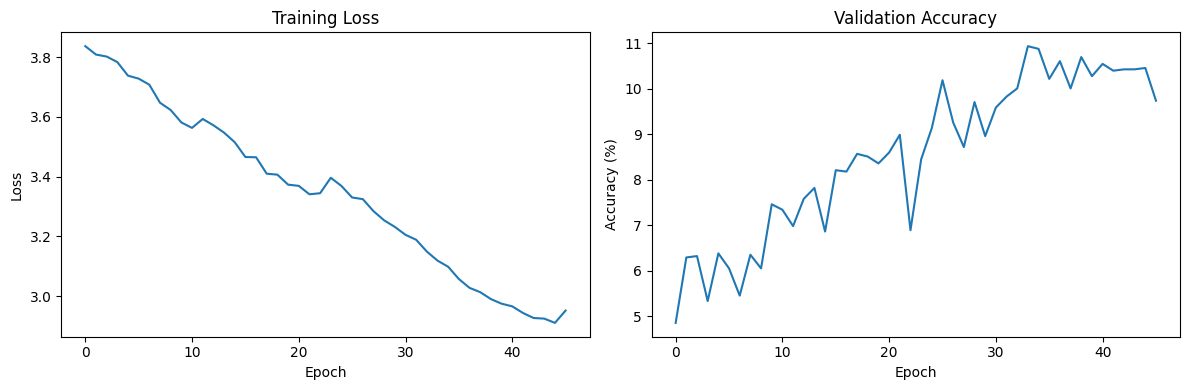


Final Results:
Best Validation Accuracy: 10.94%
Best Validation F1 Score: 8.67%


In [ ]:
#  Train the model
device = torch.device("cpu")
print(f"Using device: {device}")
print("Starting training...")
best_acc, best_f1 = train_and_evaluate_improved(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    num_classes=NUM_CLASSES,
    num_epochs=NUM_EPOCHS,
    accumulation_steps=ACCUMULATION_STEPS,
    early_stopping=early_stopping
)

print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {best_acc:.2f}%")
print(f"Best Validation F1 Score: {best_f1:.2f}%")

In [9]:
complex_model = MotionTransformerClassifier(
    num_classes=NUM_CLASSES,
    input_dim=9,
    d_model=D_MODEL,
    n_head=N_HEAD,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to("cuda")

model = complex_model
print("Model Arch: ")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)
# Optimizer and scheduler
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

# Use CosineAnnealingWarmRestarts for better convergence
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,  # Restart every 10 epochs
    T_mult=2,
    eta_min=LEARNING_RATE * 0.01
)

# Loss function with class weights
class_weights_loss = calculate_class_weights(train_df, NUM_CLASSES, power=0.25)
criterion = nn.CrossEntropyLoss(
    weight=class_weights_loss.to("cuda"), # Corrected device
    label_smoothing=0.05  # Reduced label smoothing
)

# Early stopping
early_stopping = EarlyStopping(patience=15, min_delta=0.001)

#  Train the model
device = torch.device("cpu")
print(f"Using device: {device}")
print("Starting training...")
best_acc, best_f1 = train_and_evaluate_improved(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    num_classes=NUM_CLASSES,
    num_epochs=NUM_EPOCHS,
    accumulation_steps=ACCUMULATION_STEPS,
    early_stopping=early_stopping
)

print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {best_acc:.2f}%")
print(f"Best Validation F1 Score: {best_f1:.2f}%")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model Arch: 
Model parameters: 2,345,268
MotionTransformerClassifier(
  (input_proj): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
  )
  (spatial_aggregator): MultiScaleSpatialAggregator(
    (spatial_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (global_pool_proj): Linear(in_features=128, out_features=128, bias=True)
    (point_attention): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
      (3): Sigmoid()
    )
    (fusion): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
    )
  )
  (embedding): Sequential(
    (0): Linear(in_features=1

Epoch 1/100:   0%|          | 0/442 [00:00<?, ?it/s]

Device inside is cuda


Epoch 1/100:   0%|          | 0/442 [00:18<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 38.86 GiB. GPU 0 has a total capacity of 39.56 GiB of which 28.62 GiB is free. Process 4081 has 10.93 GiB memory in use. Of the allocated memory 10.40 GiB is allocated by PyTorch, and 42.03 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)